## Start of Random Forest Classifier

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Dataset changes depending on what method we are using to test the model
# If you are using Google colab
'''
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data Sets/intended_1-to-1_few.csv") # Change this depending on where your dataset is located
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
'''
#If you are using local files, assuming the file is in the same folder 
df = pd.read_csv('R Analyzing and Preprocessing + Multilayer Perceptron/intended_1-to-1_few.csv')

Mounted at /content/drive


## Data Preprocessing

In [2]:
print(f'Dataset shape : {df.shape}')
print(df['Patient_ID'].nunique())

# Orinigal dataset has 44 columns and 1,555,221 rows
# There are a total of 40,336 unique patients, all with varying amount of presence
#df.describe()

Dataset shape : (40336, 13)
40336


In [3]:
print("Duplicates:", df.duplicated().sum())
var_list = (df.isna().sum() / len(df) * 100)

print("Missing Values Percentage:\n", (var_list.sort_values()))

Duplicates: 0
Missing Values Percentage:
 Male            0.000000
Patient_ID      0.000000
SepsisLabel     0.000000
Female          0.000000
Age             0.000000
HR             74.038080
O2Sat          74.704978
MAP            74.789270
Resp           75.119000
SBP            75.932170
DBP            81.478084
Temp           81.537584
EtCO2          98.837267
dtype: float64


In [4]:
# Duplicate Column that needs to be dropped
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

required_cols = ['Patient_ID', 'SepsisLabel']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' not found in dataset.")

# Sort them in order
sort_cols = ['Patient_ID']
if 'Hour' in df.columns:
    sort_cols.append('Hour')
elif 'ICULOS' in df.columns:
    sort_cols.append('ICULOS')

df = df.sort_values(sort_cols).reset_index(drop=True)

# Add support for Gender column
if 'Gender' in df.columns and df['Gender'].dtype == object:
    df['Gender'] = df['Gender'].map({'M': 1, 'F': 0, 'Male': 1, 'Female': 0})

for col in df.columns:
    if col != 'Patient_ID':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Cleaned shape:', df.shape)


Cleaned shape: (40336, 13)


## Sampling Method (Old version)

In [5]:
'''
df_true = df[df['SepsisLabel'] == 1]
df_false = df[df['SepsisLabel'] == 0]

df_false = df.sample(n=27916, weights="Patient_ID")

df_new = pd.concat([df_true, df_false], ignore_index=True)
df = df_new.copy()


df_new = df.sample(frac=0.05, weights="Patient_ID")
df = df_new.copy()

#print(df_true.info())
print(df.shape)
#print(df_new.info())
'''

'\ndf_true = df[df[\'SepsisLabel\'] == 1]\ndf_false = df[df[\'SepsisLabel\'] == 0]\n\ndf_false = df.sample(n=27916, weights="Patient_ID")\n\ndf_new = pd.concat([df_true, df_false], ignore_index=True)\ndf = df_new.copy()\n\n\ndf_new = df.sample(frac=0.05, weights="Patient_ID")\ndf = df_new.copy()\n\n#print(df_true.info())\nprint(df.shape)\n#print(df_new.info())\n'

## Train / Validation / Test Split

In [6]:
# ---------------------------------------------------------------------------------
# Train/Test by grouping patient IDs together
# ---------------------------------------------------------------------------------

TRAIN_SIZE = 0.90
TEST_SIZE  = 0.10

unique_patients = df['Patient_ID'].unique()


# All features
baseline_candidate_features = ['Hour','HR','O2Sat','Temp','SBP','MAP','DBP','Resp','EtCO2','BaseExcess','HCO3','FiO2','pH','PaCO2','SaO2','AST','BUN','Alkalinephos','Calcium','Chloride','Creatinine','Bilirubin_direct',
                               'Glucose','Lactate','Magnesium','Phosphate','Potassium','Bilirubin_total','TroponinI','Hct','Hgb','PTT','WBC','Fibrinogen','Platelets','Age','Gender','Unit1','Unit2','HospAdmTime','ICULOS','SepsisLabel','Patient_ID']

# Limiting the amount of features
'''
baseline_candidate_features = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp', 'DBP',
    'Age', 'Gender', 'ICULOS', 'HospAdmTime', 'Unit1', 'Unit2'
]
'''

baseline_feature_cols = [col for col in baseline_candidate_features if col in df.columns]
# baseline_feature_cols

def patient_fill(dataframe, feature_cols):
    filled = dataframe.copy()
    filled[feature_cols] = filled.groupby('Patient_ID')[feature_cols].ffill()
    filled[feature_cols] = filled.groupby('Patient_ID')[feature_cols].bfill()
    return filled

train_patients, test_patients = train_test_split(
    unique_patients,
    test_size= TEST_SIZE,
    random_state=40
)

train_df = df[df['Patient_ID'].isin(train_patients)].copy()
test_df = df[df['Patient_ID'].isin(test_patients)].copy()

train_ = patient_fill(train_df, baseline_feature_cols)
test_  = patient_fill(test_df, baseline_feature_cols)

# Undersampling

df_true_t = train_[df['SepsisLabel'] == 1]
df_false_t = train_[df['SepsisLabel'] == 0]

print(df_true_t.shape)
print(df_false_t.shape)

df_false_t = df_false_t.sample(n=2669)
print(df_false_t.shape)

train_ = pd.concat([df_true_t, df_false_t], ignore_index=True)
test_ = test_.sample(n=938)

X_train = train_.drop(columns=['SepsisLabel','Patient_ID'])
y_train = train_['SepsisLabel']

X_test = test_.drop(columns=['SepsisLabel', 'Patient_ID'])
y_test = test_['SepsisLabel']


print('Train shape:', train_.shape)
print('Test shape:', test_.shape)
print('Test shape New:', test_.shape)
print('Train patients:', len(train_patients))
print('Test patients:', len(test_patients))

(2617, 13)
(33685, 13)
(2669, 13)
Train shape: (5286, 13)
Test shape: (938, 13)
Test shape New: (938, 13)
Train patients: 36302
Test patients: 4034


/tmp/ipykernel_3526/3228928525.py:46: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_true_t = train_[df['SepsisLabel'] == 1]
/tmp/ipykernel_3526/3228928525.py:47: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_false_t = train_[df['SepsisLabel'] == 0]


## Random Forest — Parameter Declaration

In [7]:
RF_PARAMETERS = dict(

    # Main RF parameters
    n_estimators      = 300,        # Number of trees in the forest
    criterion         = 'gini',     # Split quality metric: 'gini' | 'entropy' | 'log_loss'
    max_depth         = None,         # Max depth per tree (None = grow until pure)
    min_samples_split = 10,          # Min samples required to split a node
    min_samples_leaf  = 10,          # Min samples required at a leaf node
    min_weight_fraction_leaf = 0.0, # Min weighted fraction of total weights at a leaf
    max_features      = 'sqrt',     # Features considered per split: 'sqrt'|'log2'|int|float
    max_leaf_nodes    = None,       # Max number of leaf nodes (None = unlimited)
    min_impurity_decrease = 0.0,    # A split is made only if impurity decreases by this much
    ccp_alpha         = 0.0,        # Complexity parameter for Minimal Cost-Complexity Pruning

    # Bootstrapping / sampling
    bootstrap         = True,       # Whether to use bootstrap samples
    oob_score         = True,       # Use out-of-bag samples to estimate generalisation
    max_samples       = None,       # Samples per tree if bootstrap=True (None = full dataset)
    class_weight      = 'balanced_subsample',       # None | 'balanced' | 'balanced_subsample' | dict
    n_jobs=-1

)

## Training and Validation

In [8]:
# Training
rf_model = RandomForestClassifier(**RF_PARAMETERS)
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=10,
                       min_samples_split=10, n_estimators=300, n_jobs=-1,
                       oob_score=True)

In [9]:
# Training Scores -> To check for overfitting
y_train_pred = rf_model.predict(X_train)

print('=== Training Set ===')
print(f'Accuracy    : {accuracy_score(y_train, y_train_pred):.4f}')
print(f'Recall      : {recall_score(y_train, y_train_pred, average="binary"):.4f}')
print(f'Precision   : {precision_score(y_train, y_train_pred, average="binary"):.4f}')
print(f'F1-Score   : {f1_score(y_train, y_train_pred, average="binary"):.4f}')


print("---------------------------------------------------------------------------------")


=== Training Set ===
Accuracy    : 0.8534
Recall      : 0.7998
Precision   : 0.8929
F1-Score   : 0.8438
---------------------------------------------------------------------------------


## Testing and Evaluation

In [10]:
y_test_pred = rf_model.predict(X_test)
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_sensitivity = recall_score(y_test, y_test_pred, average='binary')
test_precision = precision_score(y_test, y_test_pred, average='binary')
test_f1score = f1_score(y_test, y_test_pred, average='binary')
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print('=== Test Set ===')
print(f'Accuracy    : {test_accuracy:.4f}')
print(f'Recall      : {test_sensitivity:.4f}')
print(f'Precision   : {test_precision:.4f}')
print(f'F1-Score   : {test_f1score:.4f}')
print(f'ROC-AUC     : {test_roc_auc:.4f}')
print()


=== Test Set ===
Accuracy    : 0.8699
Recall      : 0.7123
Precision   : 0.3399
F1-Score   : 0.4602
ROC-AUC     : 0.8069



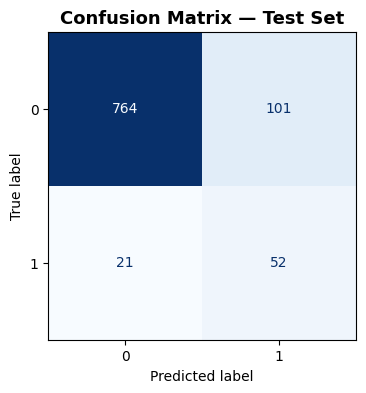

In [11]:
# Confusion Matrix

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.show()

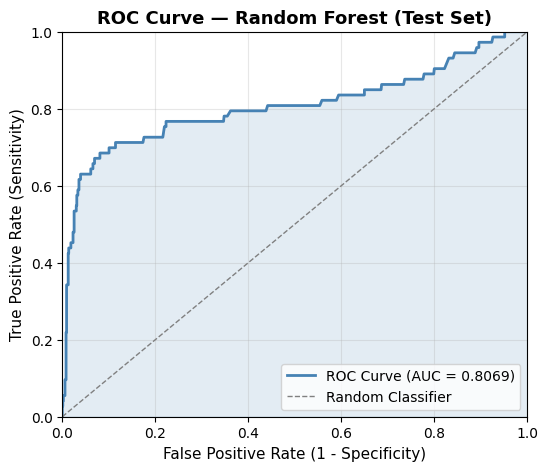

In [12]:
# ROC Curve with AUC

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

fig, axes = plt.subplots(figsize=(6, 5))
axes.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {test_roc_auc:.4f})')
axes.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random Classifier')
axes.fill_between(fpr, tpr, alpha=0.15, color='steelblue')
axes.set_xlim([0.0, 1.0])
axes.set_ylim([0.0, 1.0])
axes.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
axes.set_title('ROC Curve — Random Forest (Test Set)', fontsize=13, fontweight='bold')
axes.legend(loc='lower right', fontsize=10)
axes.grid(alpha=0.3)

plt.show()

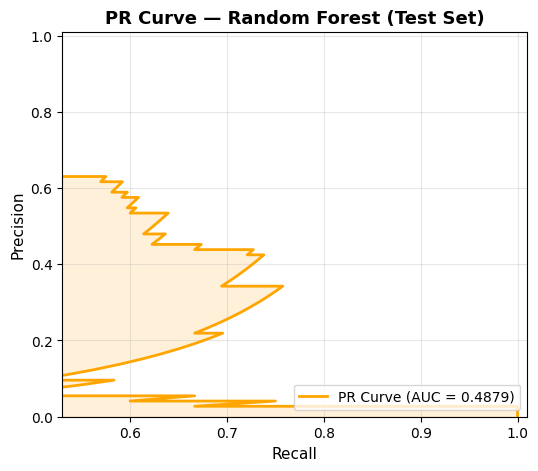

In [13]:
# PR Curve with AUC

preci, recal, thresholds = precision_recall_curve(y_test, y_test_prob)

fig, axes = plt.subplots(figsize=(6, 5))
axes.plot(preci, recal, color='orange', lw=2, label=f'PR Curve (AUC = {auc(recal, preci):.4f})')
axes.fill_between(preci, recal, alpha=0.15, color='orange')
axes.set_xlim([0.53, 1.01])
axes.set_ylim([0.0, 1.01])
axes.set_xlabel('Recall', fontsize=11)
axes.set_ylabel('Precision', fontsize=11)
axes.set_title('PR Curve — Random Forest (Test Set)', fontsize=13, fontweight='bold')
axes.legend(loc='lower right', fontsize=10)
axes.grid(alpha=0.3)

plt.show()

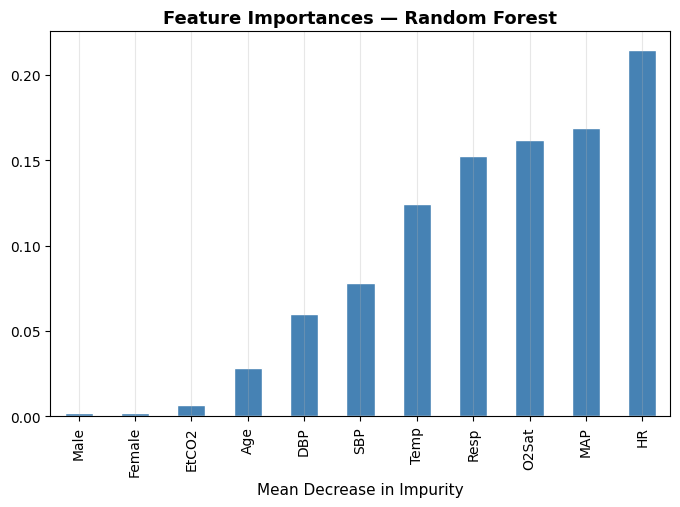

In [14]:
# Importance

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_sorted.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.show()